In [1]:
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
import os

from math import sqrt


In [216]:
os.getcwd()

'/Users/sheetalsuwalka/Documents/Resume/Assignments/Agoda Assignment'

In [262]:
df_A = pd.read_excel('Case_Study_Urgency_Message_Data.xlsx', sheet_name = 'City_A')
df_A = df_A.drop(columns = ['#'])
df_A['day_before_checkin'] = (df_A['checkin_date'] - df_A['booking_date']).dt.days
df_A.head()

,ADR_USD,hotel_id,city_id,star_rating,accommadation_type_name,chain_hotel,booking_date,checkin_date,checkout_date,day_before_checkin
0,71.06,297388,9395,2.5,Hotel,non-chain,2016-08-02,2016-10-01,2016-10-02,60
1,76.56,298322,9395,3.0,Hotel,non-chain,2016-08-02,2016-10-01,2016-10-02,60
2,153.88,2313076,9395,5.0,Hotel,chain,2016-08-02,2016-10-01,2016-10-02,60
3,126.60,2240838,9395,3.5,Hotel,non-chain,2016-08-04,2016-10-02,2016-10-03,59
4,115.08,2240838,9395,3.5,Hotel,non-chain,2016-08-04,2016-10-02,2016-10-03,59


### Getting Avg price on Check in day for each hotel

In [263]:
df_A_filtered = df_A[df_A['day_before_checkin'] == 0]
## grouping by hotelid and checkin date and averaging the daily prices to get avg price on checkin date for a hotel
Avg_price_on_booking_day =  df_A_filtered.groupby(['hotel_id','checkin_date'], as_index=False).agg({'ADR_USD':'mean'})
Avg_price_on_booking_day = Avg_price_on_booking_day.rename(columns = {"ADR_USD": "Checkin_day_avg_price"})

### QC the data
Avg_price_on_booking_day[Avg_price_on_booking_day['hotel_id']== 21308].head()

,hotel_id,checkin_date,Checkin_day_avg_price
93,21308,2016-10-01,103.22
94,21308,2016-10-07,107.06
95,21308,2016-10-08,109.73
96,21308,2016-10-14,100.08
97,21308,2016-10-26,108.74


In [264]:
## joining both the data
df_A_price = pd.merge(df_A, Avg_price_on_booking_day, on=['hotel_id','checkin_date'])
# df_A_price.tail(10)

## Getting price change from date to booking to checkin date
## Assuming price increases, as the checkin day comes close
## +ve  price_change indicates that prices are high on checkin day
df_A_price['price_change'] = df_A_price['Checkin_day_avg_price']-  df_A_price['ADR_USD']
df_A_price.head()

,ADR_USD,hotel_id,city_id,star_rating,accommadation_type_name,chain_hotel,booking_date,checkin_date,checkout_date,day_before_checkin,Checkin_day_avg_price,price_change
0,71.06,297388,9395,2.5,Hotel,non-chain,2016-08-02,2016-10-01,2016-10-02,60,57.64,-13.42
1,58.62,297388,9395,2.5,Hotel,non-chain,2016-08-09,2016-10-01,2016-10-04,53,57.64,-0.98
2,79.56,297388,9395,2.5,Hotel,non-chain,2016-08-20,2016-10-01,2016-10-02,42,57.64,-21.92
3,63.16,297388,9395,2.5,Hotel,non-chain,2016-09-05,2016-10-01,2016-10-03,26,57.64,-5.52
4,59.00,297388,9395,2.5,Hotel,non-chain,2016-09-09,2016-10-01,2016-10-03,22,57.64,-1.36


### Explore different methods to show the price movement trend (for Example, at hotel rating , hotel_id, hotel type level

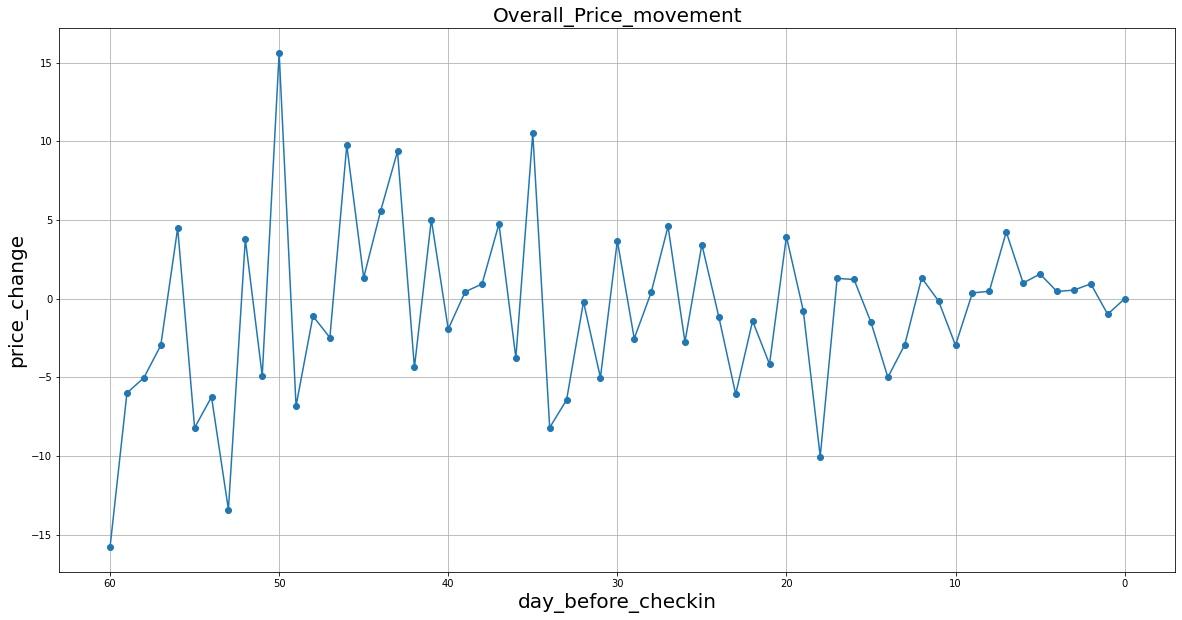

In [265]:
### At Overall aggregation level of days_before checkin
price_change_overall = df_A_price.groupby(['day_before_checkin'], as_index = False).agg({'price_change':'mean'})
price_change_overall_sorted = price_change_overall.sort_values(by = ['day_before_checkin'], ascending =  False)

plt.figure(figsize=(20, 10))
plt.plot(price_change_overall_sorted['day_before_checkin'], price_change_overall_sorted['price_change'], marker='o', linestyle='-')
plt.title('Overall_Price_movement', fontsize = 20)
plt.xlabel('day_before_checkin', fontsize = 20)
plt.ylabel('price_change', fontsize = 20)
plt.grid(True)
plt.gca().invert_xaxis() 
plt.show()

/var/folders/y5/sqxvp96j7kq4n2yv8qbqmyc80000gn/T/ipykernel_27492/2997405589.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_change_rating_filtered['star_rating'] = price_change_rating_filtered['star_rating'].astype(str) + ' star'


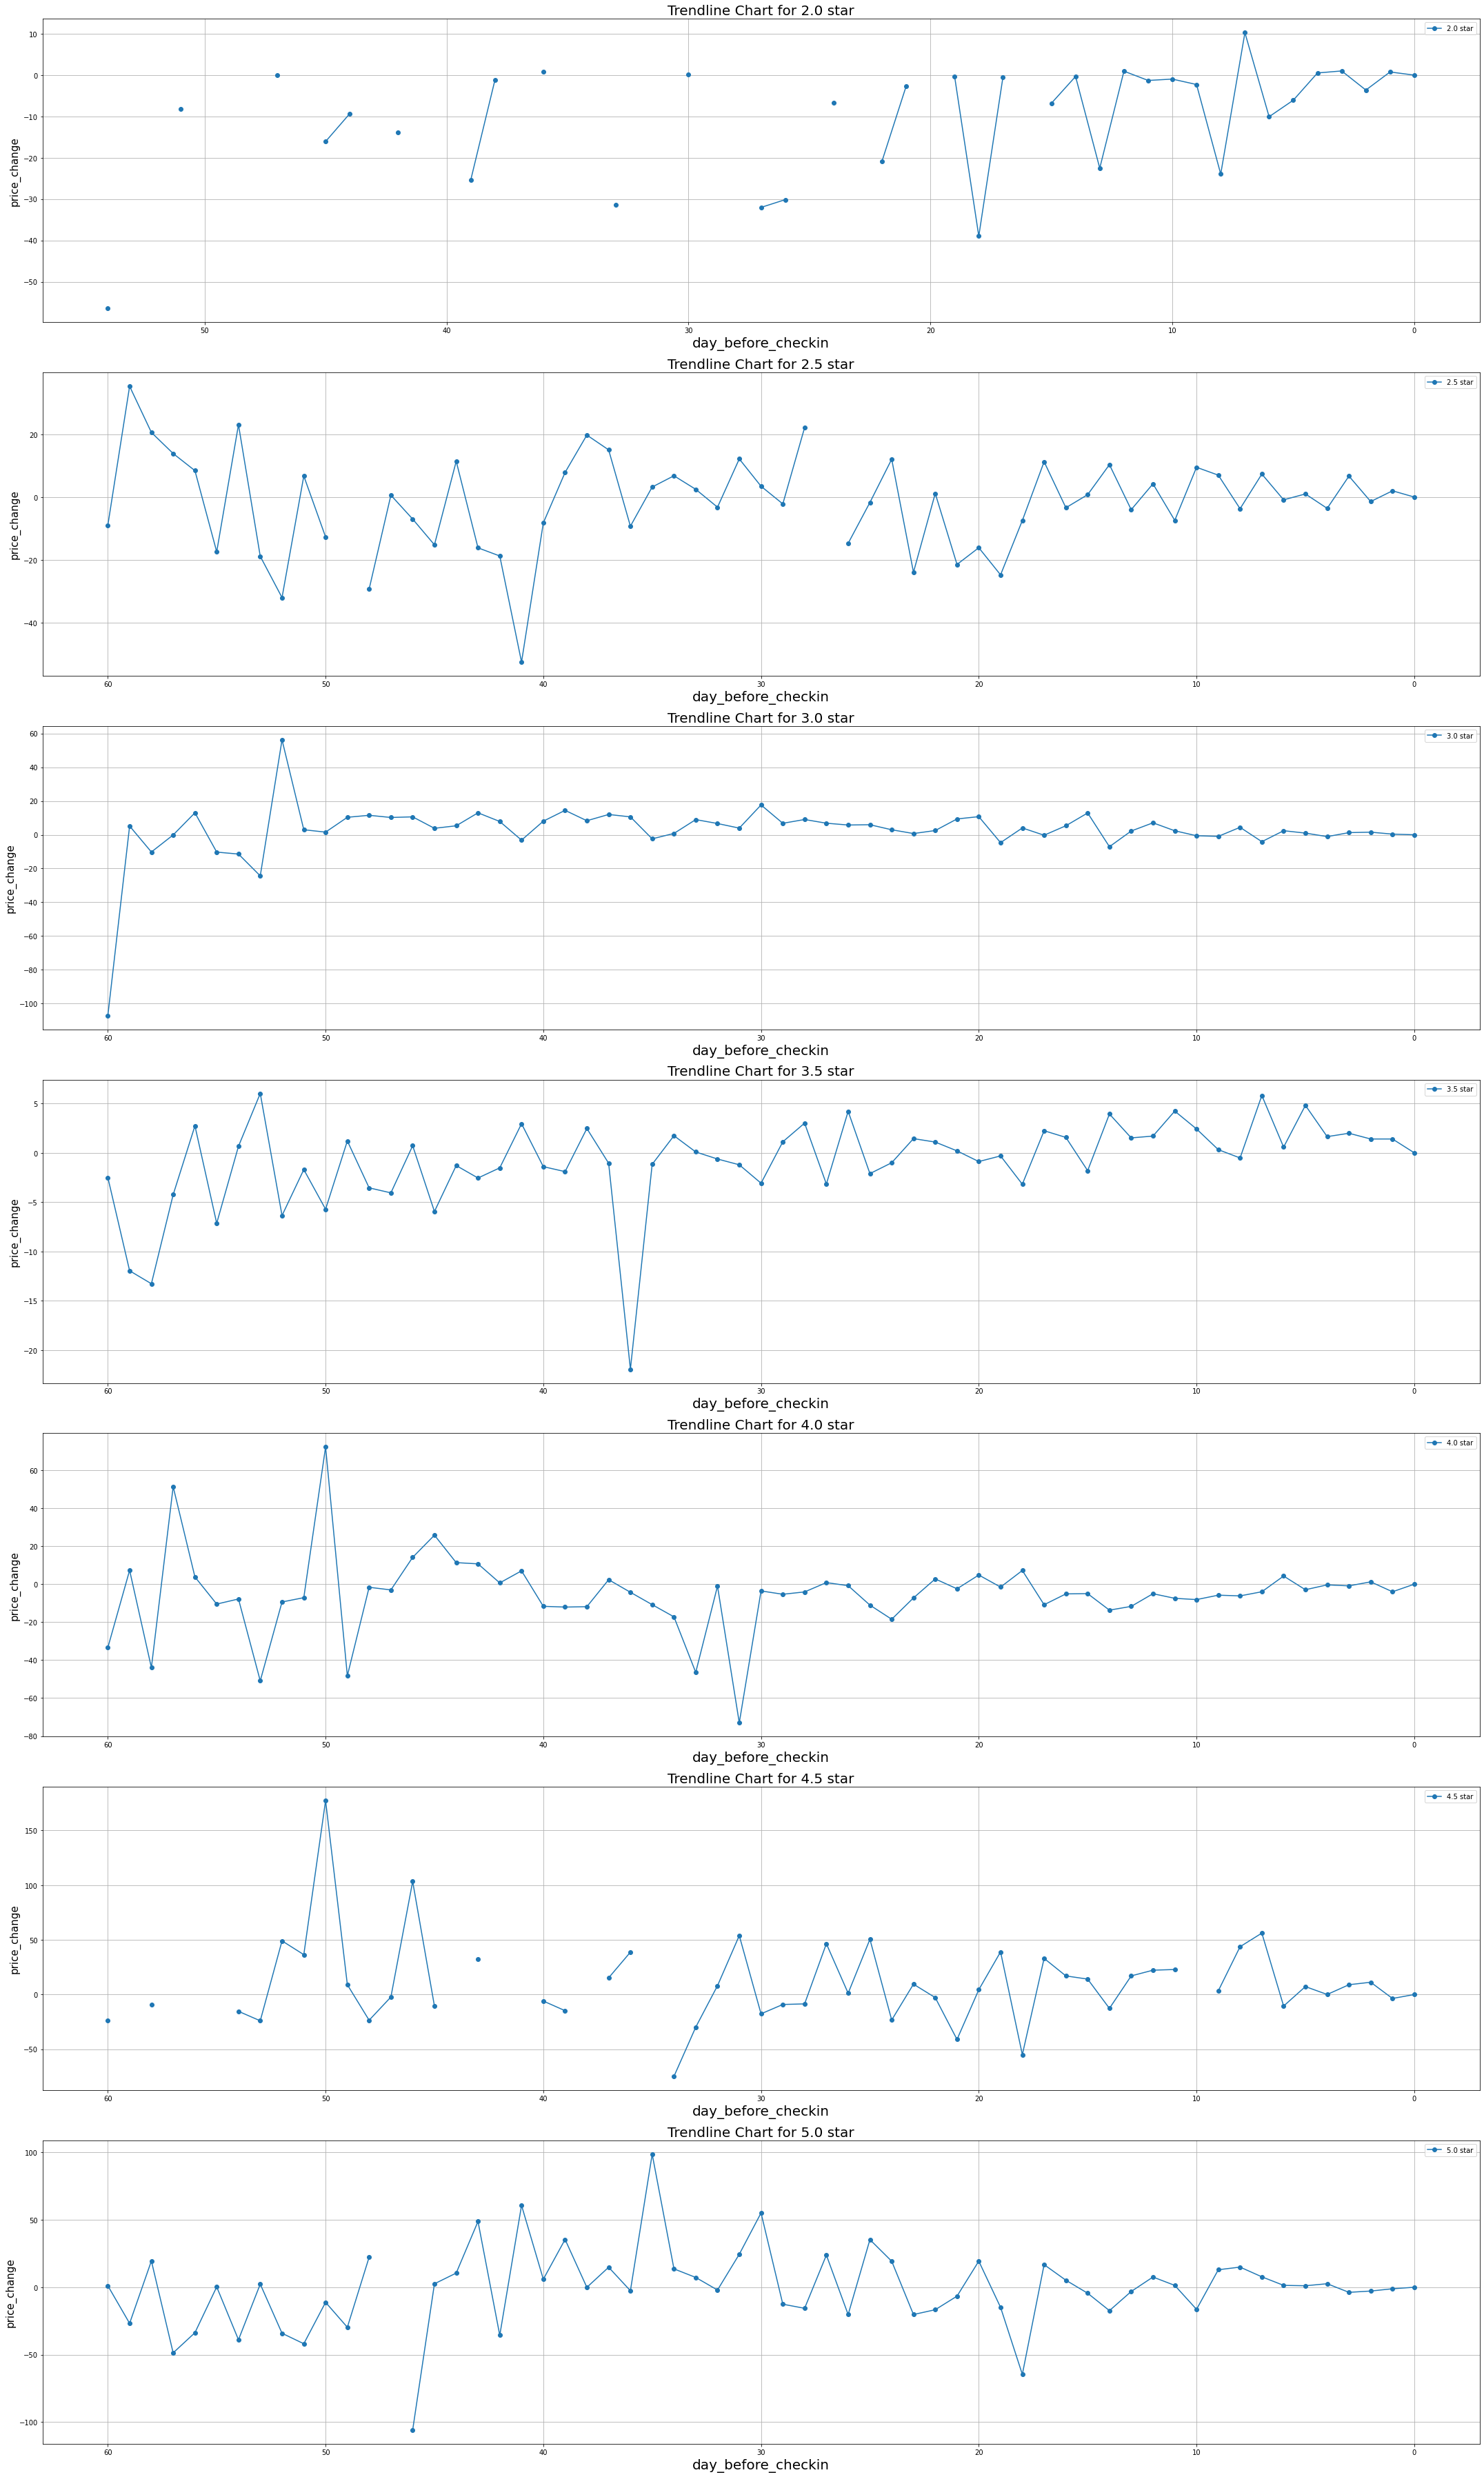

In [266]:
### At Rating level of days_before checkin
price_change_rating = df_A_price.groupby(['star_rating','day_before_checkin'], as_index = False).agg({'price_change':'mean'})
# price_change_overall_sorted = price_change_overall.sort_values(by = ['day_before_checkin'], ascending =  False)

## Filtering dataset only for 2+ star rating
price_change_rating_filtered = price_change_rating[price_change_rating['star_rating'] >= 2]
price_change_rating_filtered['star_rating'] = price_change_rating_filtered['star_rating'].astype(str) + ' star'


## pivoting the dataframe to bring rating values as column name
price_change_rating_pivot = price_change_rating_filtered.pivot(index='day_before_checkin', columns='star_rating', values='price_change')
# price_change_rating_pivot = price_change_rating_pivot.fillna(0)

price_change_rating_pivot.reset_index(inplace=True)

fig, axs = plt.subplots(7, figsize=(30, 50))

for i, col in enumerate(price_change_rating_pivot.columns[1:]):
    price_change_rating_pivot.plot(x='day_before_checkin', y=col, ax=axs[i], marker='o', linestyle='-')
    axs[i].set_title(f'Trendline Chart for {col}', fontsize = 20)
    axs[i].set_xlabel('day_before_checkin', fontsize = 20)
    axs[i].set_ylabel('price_change', fontsize = 15)
    axs[i].invert_xaxis() 
    axs[i].grid(True)
    
plt.tight_layout()
plt.show()

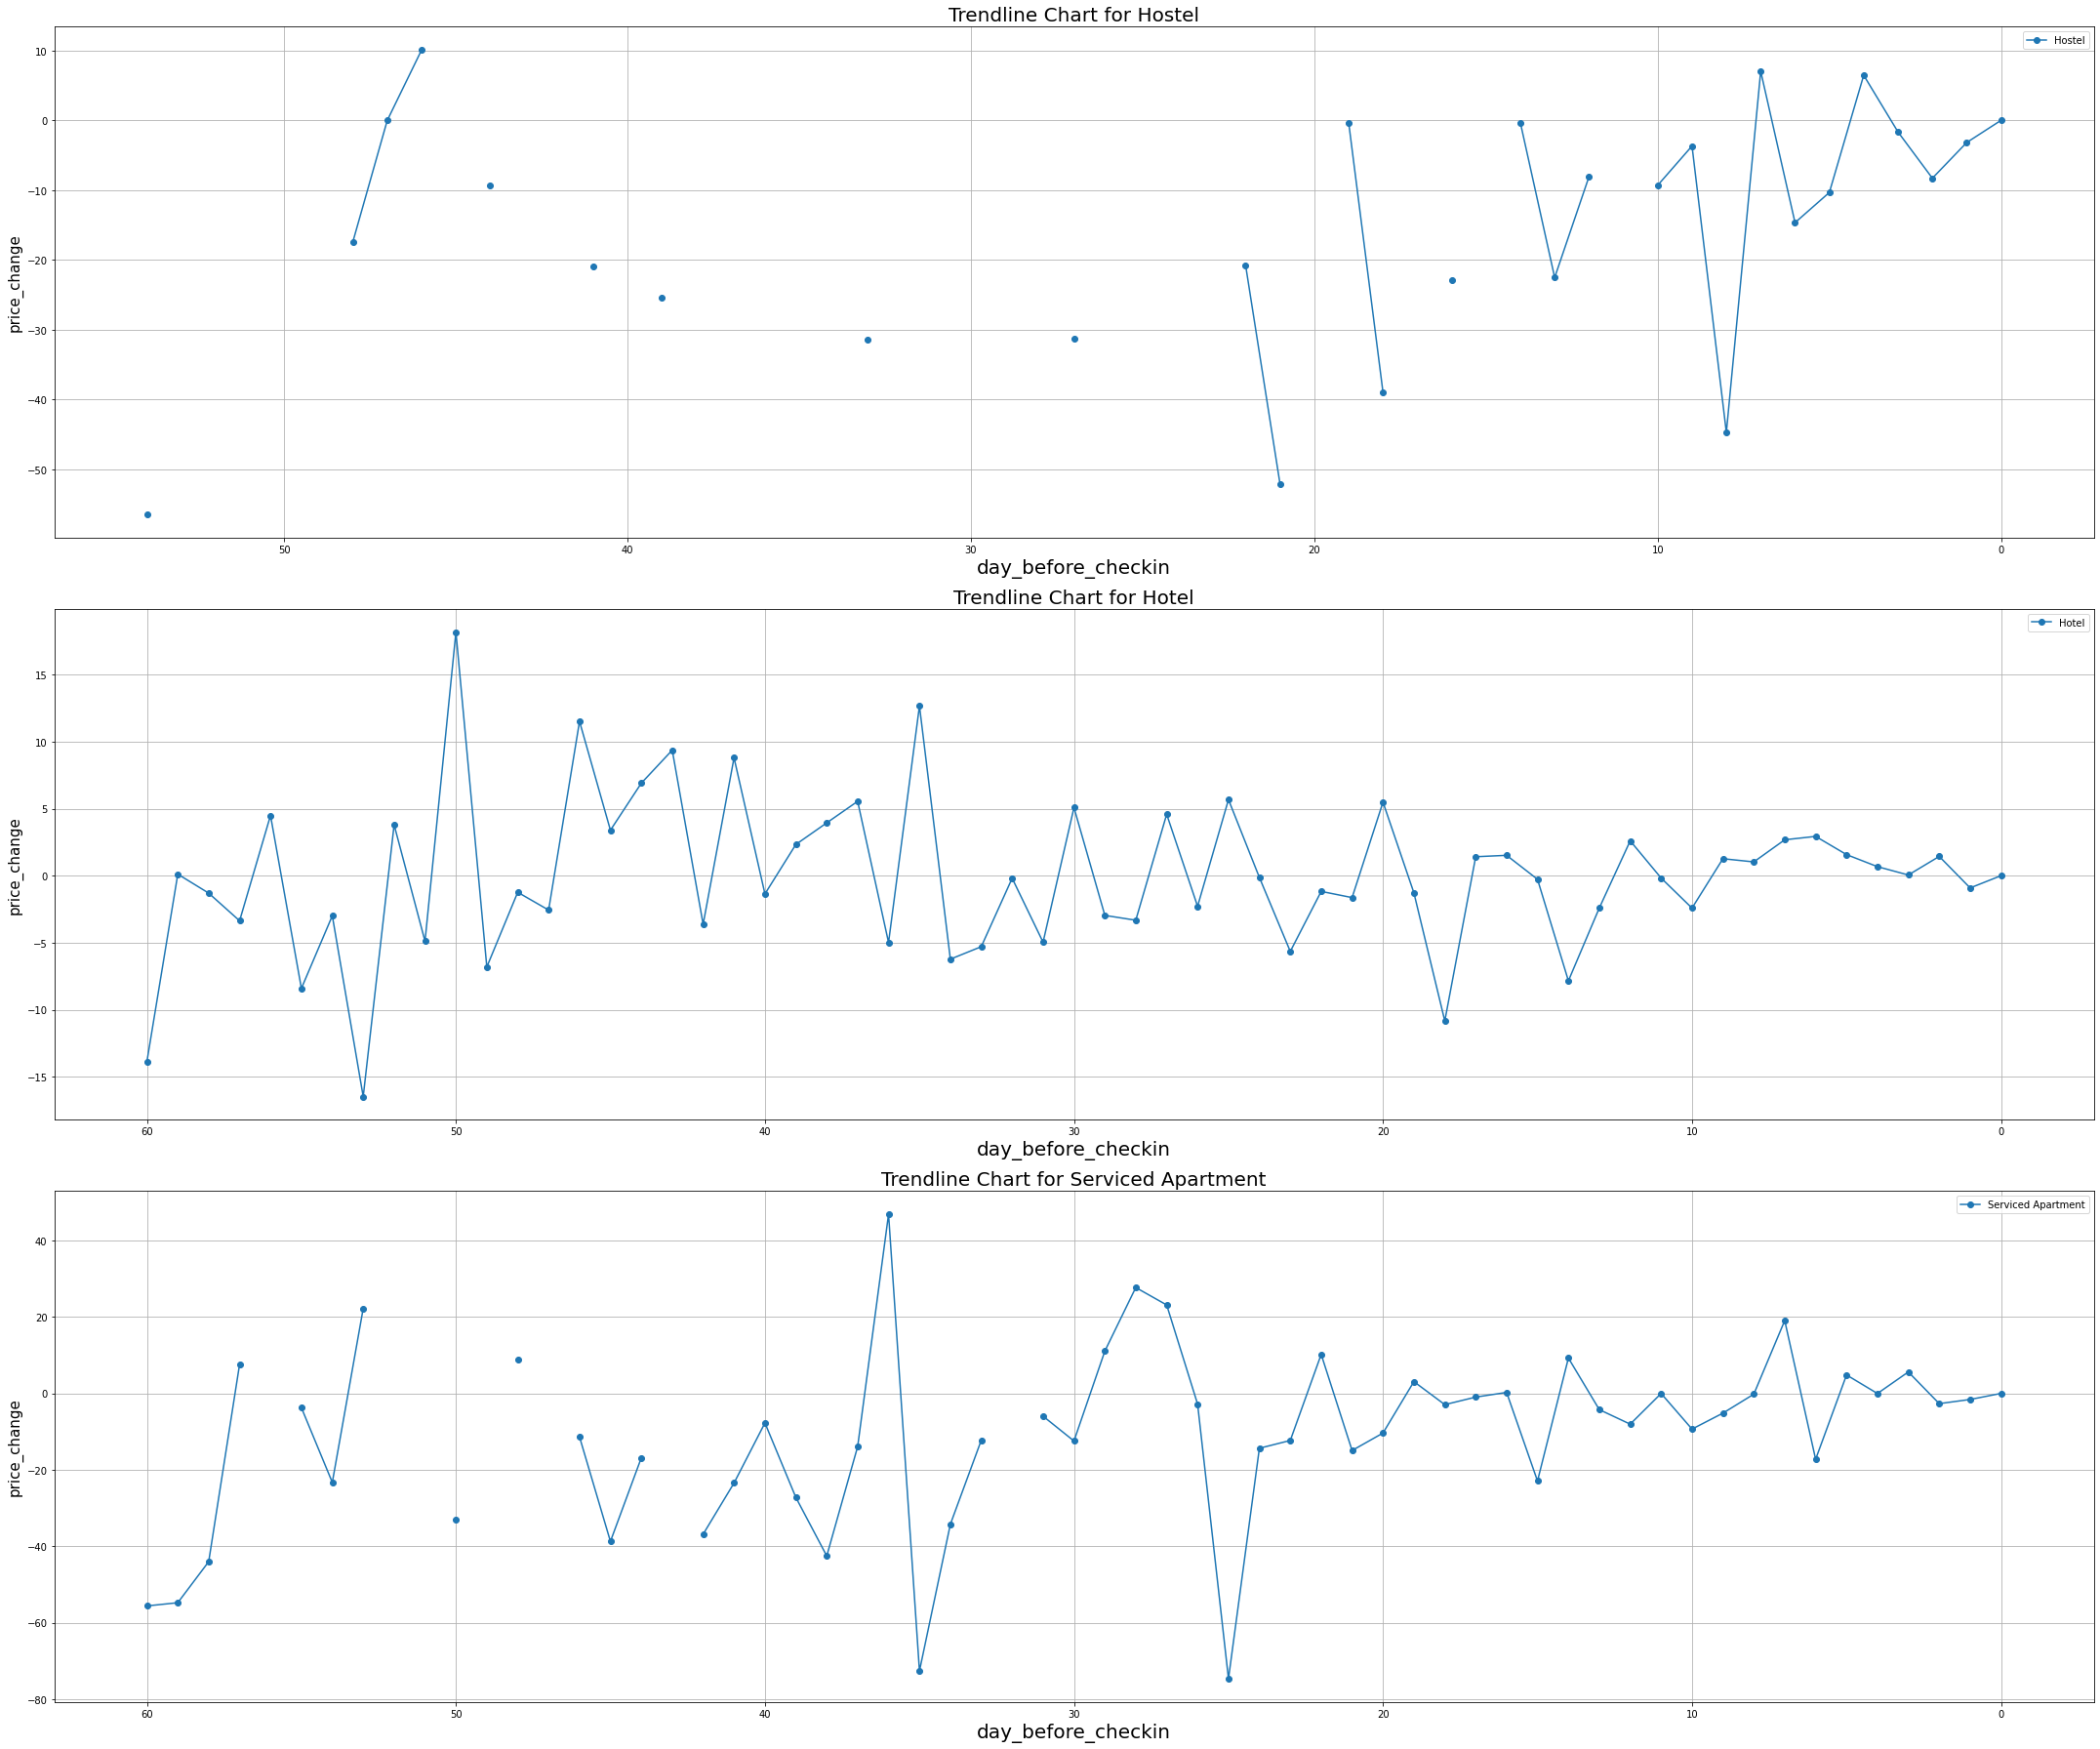

In [267]:
### At Rating aggregation level of days_before checkin

price_change_type = df_A_price.groupby(['accommadation_type_name','day_before_checkin'], as_index = False).agg({'price_change':'mean'})

## Filtering dataset only the category with data
price_change_type = price_change_type[price_change_type['accommadation_type_name'].isin(['Hostel','Hotel', 'Serviced Apartment'])]

## pivoting the dataframe to bring rating values as column name
price_change_type_pivot = price_change_type.pivot(index='day_before_checkin', columns='accommadation_type_name', values='price_change')
# price_change_rating_pivot = price_change_rating_pivot.fillna(0)

price_change_type_pivot.reset_index(inplace=True)

fig, axs = plt.subplots(3, figsize=(30, 25))
for i, col in enumerate(price_change_type_pivot.columns[1:]):
    price_change_type_pivot.plot(x='day_before_checkin', y=col, ax=axs[i], marker='o', linestyle='-')
    axs[i].set_title(f'Trendline Chart for {col}', fontsize = 20)
    axs[i].set_xlabel('day_before_checkin', fontsize = 20)
    axs[i].set_ylabel('price_change', fontsize = 15)
    axs[i].invert_xaxis() 
    axs[i].grid(True)
    
plt.tight_layout()
plt.show()

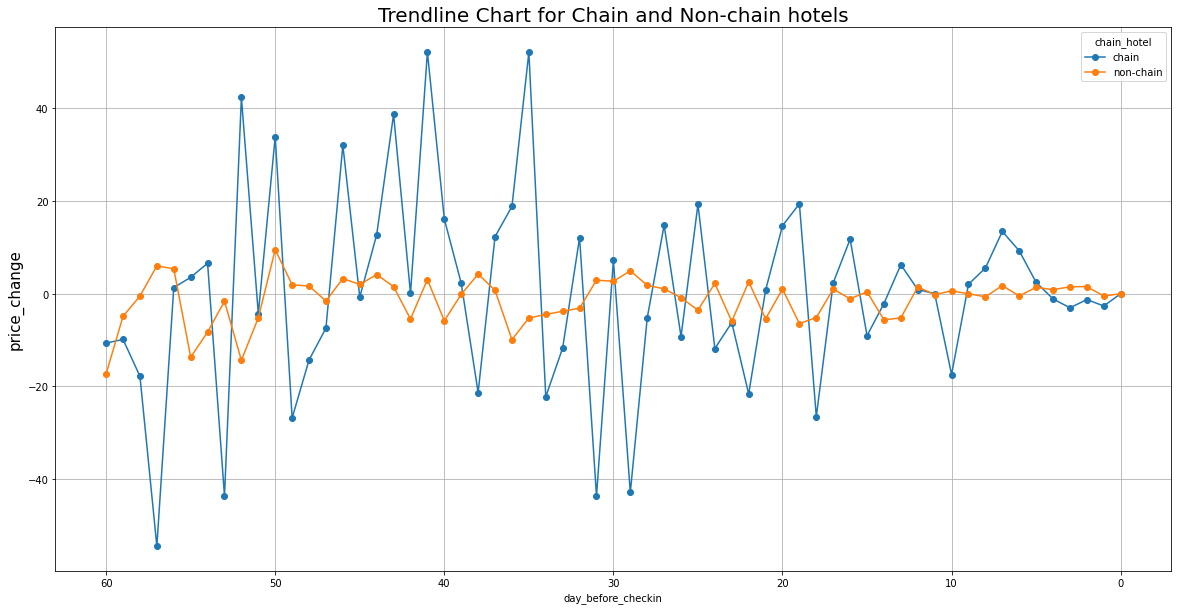

In [268]:
### At Chain Hotel aggregation level of days_before checkin

price_change_chain = df_A_price.groupby(['chain_hotel','day_before_checkin'], as_index = False).agg({'price_change':'mean'})

price_change_chain_pivot = price_change_chain.pivot(index='day_before_checkin', columns='chain_hotel', values='price_change')

price_change_chain_pivot.reset_index(inplace=True)


price_change_chain_pivot.plot(x='day_before_checkin', y=['chain','non-chain'], marker='o', linestyle='-', figsize=(20, 10))

plt.title('Trendline Chart for Chain and Non-chain hotels', fontsize = 20)
plt.xlabel('day_before_checkin', fontsize = 10)
plt.ylabel('price_change', fontsize = 15)
plt.gca().invert_xaxis() 

plt.grid(True)
plt.show()